# FYP 2: Data Analysis & Clinical Evaluation
**Author:** Sofia Binti Saiful Rizal  
**Dataset:** Nandana et al. (2026) — Upper Limb Stroke Rehabilitation Exercises  
**Pipeline:** Angular DTW classification using MediaPipe BlazePose and YOLOv8-Pose keypoints

| # | Exercise |
|---|----------|
| 1 | Lifting an Object |
| 2 | Extending the Elbow |
| 3 | Lifting the Wrist |
| 4 | Opening the Hand |

## 1. Environment Setup
Imports, dataset paths, YOLO→MediaPipe keypoint map, and shared colour palette.

In [20]:
import os, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fastdtw import fastdtw
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='paper', font_scale=1.2)

# ── Dataset root ────────────────────────────────────────────────────────
BASE = "/Users/sofiasaifulrizal/Desktop/delta_2610/FYP2/An_upper_limb_stroke_rehabilitation_exercise_video"

exercise_folder_map = {
    1: "1_Lifting an Object",
    2: "2_Extending the Elbow",
    3: "3_Lifting the Wrist",
    4: "4_Opening the Hand",
}

def get_frame_width(ex_num):
    """Image width used to normalise both x and y coordinates (MediaPipe convention)."""
    return 810.0  # Ex 2 uses 810×1800, all others 810×1440; width is 810 for all

# COCO (YOLO) → MediaPipe landmark names — upper-body joints only
yolo_to_mp_map = {
    'kp5_x':  'lm11_x', 'kp5_y':  'lm11_y', 'kp5_conf':  'lm11_vis',  # L Shoulder
    'kp6_x':  'lm12_x', 'kp6_y':  'lm12_y', 'kp6_conf':  'lm12_vis',  # R Shoulder
    'kp7_x':  'lm13_x', 'kp7_y':  'lm13_y', 'kp7_conf':  'lm13_vis',  # L Elbow
    'kp8_x':  'lm14_x', 'kp8_y':  'lm14_y', 'kp8_conf':  'lm14_vis',  # R Elbow
    'kp9_x':  'lm15_x', 'kp9_y':  'lm15_y', 'kp9_conf':  'lm15_vis',  # L Wrist
    'kp10_x': 'lm16_x', 'kp10_y': 'lm16_y', 'kp10_conf': 'lm16_vis',  # R Wrist
}

# ── Colour palette ──────────────────────────────────────────────────────
# Blue family = YOLO  |  Amber/orange family = MediaPipe  |  Purple = Baseline
# Avoids red/green (pass/fail connotations)
C = {
    'YOLO_Raw':    '#74b9e8',  # light blue
    'YOLO_Filter': '#1f77b4',  # deep blue
    'MP_Raw':      '#ffc04d',  # amber
    'MP_Filter':   '#e07b39',  # burnt orange
    'Baseline':    '#9467bd',  # purple
}

print('✅ Environment configured — Nandana et al. (2026) dataset ready.')

✅ Environment configured — Nandana et al. (2026) dataset ready.


## 2. Core Algorithms

- **`load_df`** — loads a CSV and normalises YOLO pixel coords to match MediaPipe's coordinate system (both axes ÷ FRAME_WIDTH).
- **`apply_ema_filter`** — optional EMA temporal smoothing on joint coordinates.
- **`evaluate_with_angular_dtw`** — computes the mean Angular DTW distance between patient and expert elbow-angle time series; returns *pass (1)* if distance ≤ threshold.

In [21]:
def load_df(filepath, fw_name, frame_width):
    df = pd.read_csv(filepath)
    if fw_name == 'YOLOv8':
        df.rename(columns=yolo_to_mp_map, inplace=True)
        for c in yolo_to_mp_map.values():
            if c in df.columns and ('_x' in c or '_y' in c):
                df[c] = df[c].astype(float) / frame_width
    return df

def get_files(fw_folder, ex_name):
    root = os.path.join(BASE, fw_folder, ex_name)
    complete   = sorted(glob.glob(os.path.join(root, "Complete",   "**", "*.csv"), recursive=True))
    incomplete = sorted(glob.glob(os.path.join(root, "Incomplete", "**", "*.csv"), recursive=True))
    return complete, incomplete

def apply_ema_filter(df, run_level, span=3):
    if run_level == 1 or df.empty:
        return df.copy()
    out = df.copy()
    coord_cols = [c for c in out.columns if '_x' in c or '_y' in c]
    out[coord_cols] = out[coord_cols].ewm(span=span, adjust=False).mean()
    return out

def _elbow_angle(df):
    a = df[['lm12_x','lm12_y']].values  # R shoulder
    b = df[['lm14_x','lm14_y']].values  # R elbow
    c = df[['lm16_x','lm16_y']].values  # R wrist
    ba, bc = a - b, c - b
    cos = np.sum(ba*bc, axis=1) / (np.linalg.norm(ba,axis=1)*np.linalg.norm(bc,axis=1) + 1e-10)
    angles = np.degrees(np.arccos(np.clip(cos, -1, 1)))
    return angles[~np.isnan(angles)]  # drop NaN frames (Ex4 wrist can drift out of frame)

def evaluate_with_angular_dtw(patient_df, expert_df, threshold):
    if patient_df.empty or expert_df.empty: return 0
    exp_ang = _elbow_angle(expert_df)
    pat_ang = _elbow_angle(patient_df)
    if len(exp_ang) < 5 or len(pat_ang) < 5: return 0
    try:
        dist, path = fastdtw(pat_ang, exp_ang, dist=lambda x, y: abs(x - y))
        return 1 if (dist / len(path)) <= threshold else 0
    except Exception:
        return 0

print('✅ Core algorithms loaded.')

✅ Core algorithms loaded.


## 3. Threshold Calibration (Grid Search)

Sweeps Angular DTW thresholds from 0° to 40° across all four exercises and both frameworks.  
Inspect the curves to find the threshold where each framework peaks, then update `optimal_params` in Section 4.

🚀 RUNNING THRESHOLD CALIBRATION GRID SEARCH...

📊 Exercise 1: 1_Lifting an Object


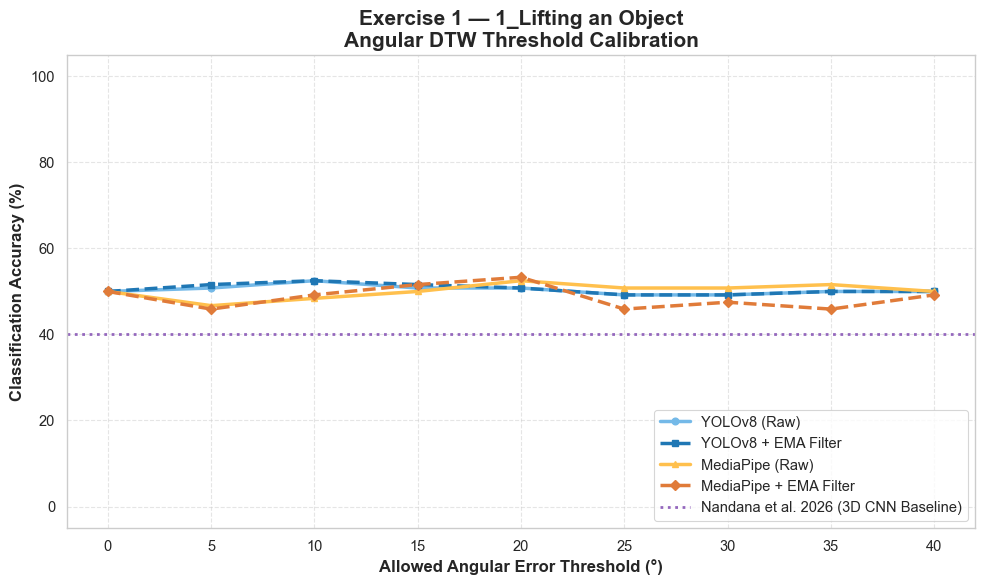

  ✅ Saved: /Users/sofiasaifulrizal/Desktop/delta_2610/FYP2/An_upper_limb_stroke_rehabilitation_exercise_video/Ex1_Angular_Threshold_Calibration.png

📊 Exercise 2: 2_Extending the Elbow


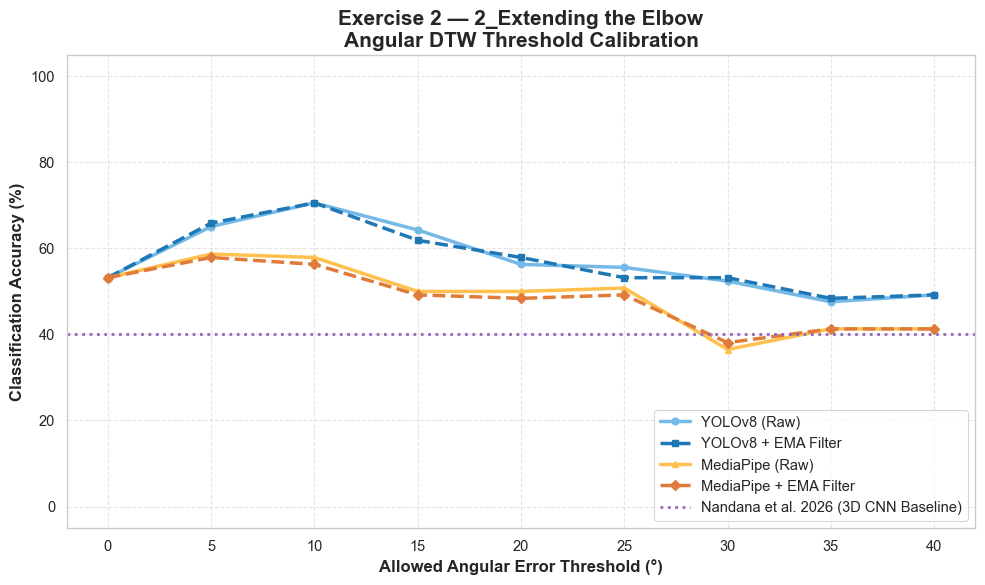

  ✅ Saved: /Users/sofiasaifulrizal/Desktop/delta_2610/FYP2/An_upper_limb_stroke_rehabilitation_exercise_video/Ex2_Angular_Threshold_Calibration.png

📊 Exercise 3: 3_Lifting the Wrist


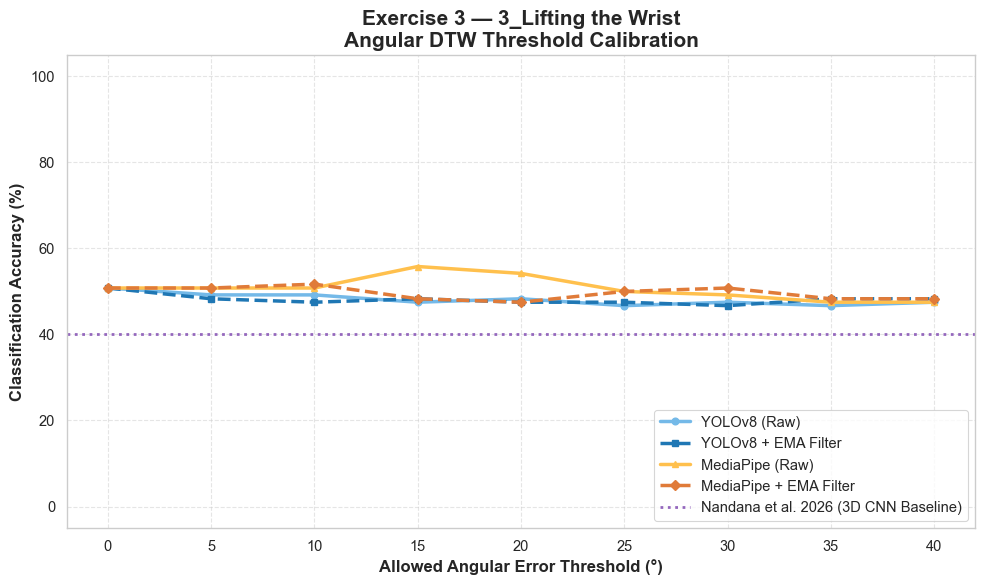

  ✅ Saved: /Users/sofiasaifulrizal/Desktop/delta_2610/FYP2/An_upper_limb_stroke_rehabilitation_exercise_video/Ex3_Angular_Threshold_Calibration.png

📊 Exercise 4: 4_Opening the Hand


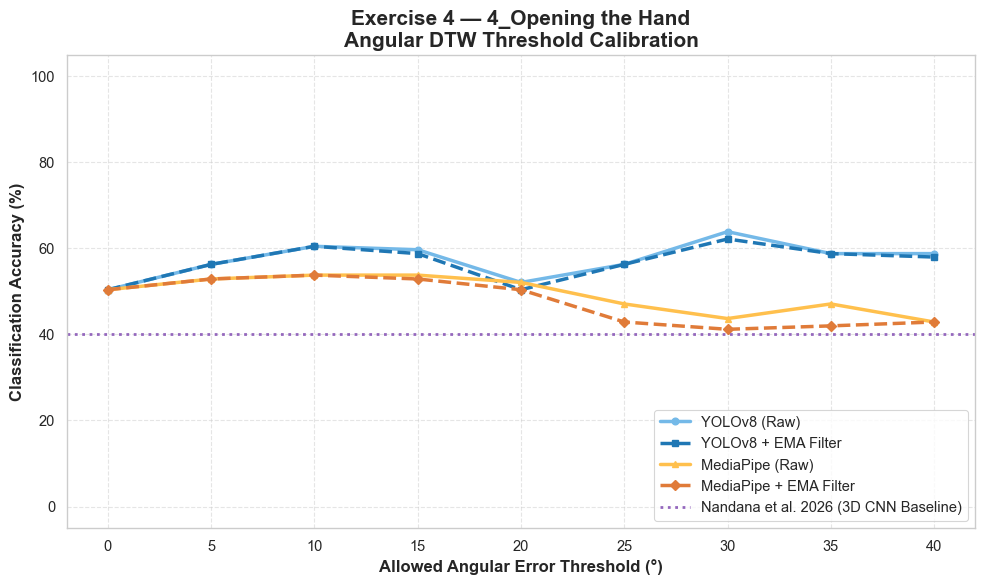

  ✅ Saved: /Users/sofiasaifulrizal/Desktop/delta_2610/FYP2/An_upper_limb_stroke_rehabilitation_exercise_video/Ex4_Angular_Threshold_Calibration.png



In [22]:
LOCKED_SPAN     = 3
test_thresholds = [0.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0, 40.0]

print('🚀 RUNNING THRESHOLD CALIBRATION GRID SEARCH...\n')

for ex_num in [1, 2, 3, 4]:
    print(f"{'='*55}\n📊 Exercise {ex_num}: {exercise_folder_map[ex_num]}\n{'='*55}")
    fw  = get_frame_width(ex_num)
    cal = {k: [] for k in ('YOLO_Raw', 'YOLO_Filter', 'MP_Raw', 'MP_Filter')}

    for fw_name in ['MediaPipe', 'YOLOv8']:
        fw_folder = 'MediaPipe_CSV' if fw_name == 'MediaPipe' else 'YOLO_CSV'
        complete, incomplete = get_files(fw_folder, exercise_folder_map[ex_num])
        all_files = complete + incomplete

        if not complete:
            print(f'  ⚠ No Complete files for {fw_name} Ex{ex_num} — skipping')
            continue

        expert_file   = complete[0]
        patient_files = [f for f in all_files if f != expert_file]
        complete_set  = set(complete)

        # Wrap expert loading so one bad file can't crash the whole exercise
        try:
            raw_expert = load_df(expert_file, fw_name, fw)
        except Exception as e:
            print(f'  ⚠ Could not load expert for {fw_name} Ex{ex_num}: {e} — skipping')
            continue

        for run_level in [1, 4]:
            expert_df = apply_ema_filter(raw_expert, run_level, LOCKED_SPAN)
            for threshold in test_thresholds:
                correct = total = 0
                for p_file in patient_files:
                    true_label = 'complete' if p_file in complete_set else 'incomplete'
                    try:
                        pat_df = apply_ema_filter(load_df(p_file, fw_name, fw), run_level, LOCKED_SPAN)
                        if pat_df.empty: continue
                        pred = 'complete' if evaluate_with_angular_dtw(pat_df, expert_df, threshold) == 1 else 'incomplete'
                        total += 1; correct += (pred == true_label)
                    except Exception:
                        pass
                acc = round(correct / total * 100, 1) if total > 0 else 0.0
                key = ('MP' if fw_name == 'MediaPipe' else 'YOLO') + ('_Raw' if run_level == 1 else '_Filter')
                cal[key].append(acc)

    # Safety: pad any short list so all 4 lines have the same length as test_thresholds
    n = len(test_thresholds)
    for key in cal:
        if len(cal[key]) < n:
            print(f'  ⚠ {key} incomplete ({len(cal[key])}/{n} values) — padding with 0.0')
            cal[key].extend([0.0] * (n - len(cal[key])))

    if not any(cal[k] for k in cal):
        print('  ❌ No data at all — check CSV folder paths.\n'); continue

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(test_thresholds, cal['YOLO_Raw'],    'o-',  color=C['YOLO_Raw'],    lw=2.5, label='YOLOv8 (Raw)')
    ax.plot(test_thresholds, cal['YOLO_Filter'], 's--', color=C['YOLO_Filter'], lw=2.5, label='YOLOv8 + EMA Filter')
    ax.plot(test_thresholds, cal['MP_Raw'],      '^-',  color=C['MP_Raw'],      lw=2.5, label='MediaPipe (Raw)')
    ax.plot(test_thresholds, cal['MP_Filter'],   'D--', color=C['MP_Filter'],   lw=2.5, label='MediaPipe + EMA Filter')
    ax.axhline(40.0, color=C['Baseline'], ls=':', lw=2, label='Nandana et al. 2026 (3D CNN Baseline)')
    ax.set_ylim(-5, 105)
    ax.set_title(f'Exercise {ex_num} — {exercise_folder_map[ex_num]}\nAngular DTW Threshold Calibration',
                 fontsize=15, fontweight='bold')
    ax.set_xlabel('Allowed Angular Error Threshold (°)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Classification Accuracy (%)', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', frameon=True)
    ax.grid(True, ls='--', alpha=0.5)
    fig.tight_layout()
    save_path = os.path.join(BASE, f'Ex{ex_num}_Angular_Threshold_Calibration.png')
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  ✅ Saved: {save_path}\n')

## 4. Final Benchmark Evaluation

Uses the optimal threshold per exercise found from the calibration curves above.  
Update `optimal_params` with the peak thresholds before running this cell.

🚀 RUNNING FINAL CALIBRATED BATCH EVALUATION...

  Ex1 | MediaPipe  | Raw → 52.5%  (64/122)
  Ex1 | MediaPipe  | EMA → 53.3%  (65/122)
  Ex1 | YOLOv8     | Raw → 50.8%  (62/122)
  Ex1 | YOLOv8     | EMA → 50.8%  (62/122)
  Ex2 | MediaPipe  | Raw → 57.9%  (73/126)
  Ex2 | MediaPipe  | EMA → 56.3%  (71/126)
  Ex2 | YOLOv8     | Raw → 70.6%  (89/126)
  Ex2 | YOLOv8     | EMA → 70.6%  (89/126)
  Ex3 | MediaPipe  | Raw → 55.8%  (67/120)
  Ex3 | MediaPipe  | EMA → 48.3%  (58/120)
  Ex3 | YOLOv8     | Raw → 47.5%  (57/120)
  Ex3 | YOLOv8     | EMA → 48.3%  (58/120)
  Ex4 | MediaPipe  | Raw → 53.8%  (64/119)
  Ex4 | MediaPipe  | EMA → 53.8%  (64/119)
  Ex4 | YOLOv8     | Raw → 60.5%  (72/119)
  Ex4 | YOLOv8     | EMA → 60.5%  (72/119)

📊 Chart saved: /Users/sofiasaifulrizal/Desktop/delta_2610/FYP2/An_upper_limb_stroke_rehabilitation_exercise_video/Nandana_2026_Final_Calibrated_BarChart.png
💾 CSV saved:   /Users/sofiasaifulrizal/Desktop/delta_2610/FYP2/An_upper_limb_stroke_rehabilitation_exercis

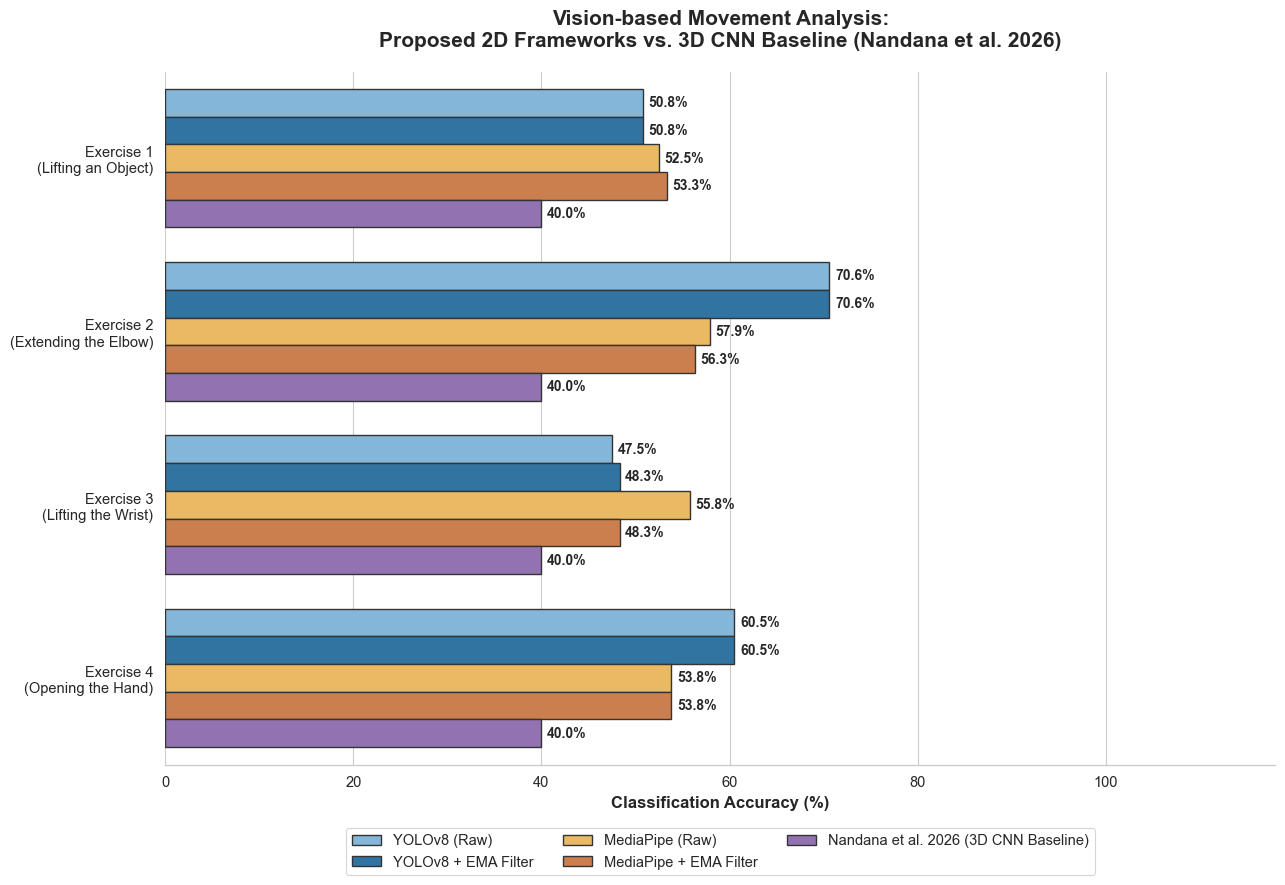

In [19]:
# Update these thresholds from the calibration curves in Section 3
optimal_params = {
    1: {'span': 3, 'threshold': 20.0},
    2: {'span': 3, 'threshold': 10.0},
    3: {'span': 3, 'threshold': 15.0},
    4: {'span': 3, 'threshold': 10.0},
}

final_results = {'YOLO_Raw': [], 'YOLO_Filter': [], 'MP_Raw': [], 'MP_Filter': []}

print('🚀 RUNNING FINAL CALIBRATED BATCH EVALUATION...\n')

for ex_num in [1, 2, 3, 4]:
    fw         = get_frame_width(ex_num)
    opt_span   = optimal_params[ex_num]['span']
    opt_thresh = optimal_params[ex_num]['threshold']

    for fw_name in ['MediaPipe', 'YOLOv8']:
        fw_folder = 'MediaPipe_CSV' if fw_name == 'MediaPipe' else 'YOLO_CSV'
        complete, incomplete = get_files(fw_folder, exercise_folder_map[ex_num])
        all_files    = complete + incomplete
        complete_set = set(complete)

        if not complete:
            for key in (['MP_Raw','MP_Filter'] if fw_name=='MediaPipe' else ['YOLO_Raw','YOLO_Filter']):
                final_results[key].append(0.0)
            continue

        expert_file   = complete[0]
        patient_files = [f for f in all_files if f != expert_file]
        raw_expert    = load_df(expert_file, fw_name, fw)

        for run_level in [1, 4]:
            expert_df = apply_ema_filter(raw_expert, run_level, opt_span)
            correct = total = 0
            for p_file in patient_files:
                true_label = 'complete' if p_file in complete_set else 'incomplete'
                try:
                    pat_df = apply_ema_filter(load_df(p_file, fw_name, fw), run_level, opt_span)
                    if pat_df.empty: continue
                    pred = 'complete' if evaluate_with_angular_dtw(pat_df, expert_df, opt_thresh)==1 else 'incomplete'
                    total += 1; correct += (pred == true_label)
                except Exception: pass
            acc = round(correct/total*100, 1) if total > 0 else 0.0
            key = ('MP' if fw_name=='MediaPipe' else 'YOLO') + ('_Raw' if run_level==1 else '_Filter')
            final_results[key].append(acc)
            label = 'Raw' if run_level==1 else 'EMA'
            print(f'  Ex{ex_num} | {fw_name:10s} | {label:3s} → {acc:.1f}%  ({correct}/{total})')

# ── Bar Chart ──────────────────────────────────────────────────────────────
exercise_labels = [
    'Exercise 1\n(Lifting an Object)',
    'Exercise 2\n(Extending the Elbow)',
    'Exercise 3\n(Lifting the Wrist)',
    'Exercise 4\n(Opening the Hand)',
]
sota_scores = [40.0, 40.0, 40.0, 40.0]

rows = []
for i, ex_name in enumerate(exercise_labels):
    if i >= len(final_results['YOLO_Raw']): break
    rows += [
        {'Exercise': ex_name, 'Pipeline': 'YOLOv8 (Raw)',                          'Accuracy': final_results['YOLO_Raw'][i]},
        {'Exercise': ex_name, 'Pipeline': 'YOLOv8 + EMA Filter',                   'Accuracy': final_results['YOLO_Filter'][i]},
        {'Exercise': ex_name, 'Pipeline': 'MediaPipe (Raw)',                        'Accuracy': final_results['MP_Raw'][i]},
        {'Exercise': ex_name, 'Pipeline': 'MediaPipe + EMA Filter',                'Accuracy': final_results['MP_Filter'][i]},
        {'Exercise': ex_name, 'Pipeline': 'Nandana et al. 2026 (3D CNN Baseline)', 'Accuracy': sota_scores[i]},
    ]

df_plot     = pd.DataFrame(rows)
bar_colours = [C['YOLO_Raw'], C['YOLO_Filter'], C['MP_Raw'], C['MP_Filter'], C['Baseline']]

fig, ax = plt.subplots(figsize=(13, 9))
sns.barplot(data=df_plot, y='Exercise', x='Accuracy', hue='Pipeline',
            palette=bar_colours, edgecolor='#333333', linewidth=1.0, ax=ax)

ax.set_title(
    'Vision-based Movement Analysis:\nProposed 2D Frameworks vs. 3D CNN Baseline (Nandana et al. 2026)',
    fontsize=15, fontweight='bold', pad=18)
ax.set_xlabel('Classification Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('')
ax.set_xlim(0, 118)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.17), ncol=3, frameon=True)

for bar in ax.patches:
    w = bar.get_width()
    if w > 0.5:
        ax.annotate(f'{w:.1f}%',
                    xy=(w, bar.get_y() + bar.get_height()/2),
                    xytext=(4, 0), textcoords='offset points',
                    ha='left', va='center', fontsize=10, fontweight='bold')

sns.despine(left=True, bottom=False)
fig.tight_layout()

chart_path = os.path.join(BASE, 'Nandana_2026_Final_Calibrated_BarChart.png')
csv_path   = os.path.join(BASE, 'Nandana_2026_Final_Calibrated_Results.csv')
fig.savefig(chart_path, dpi=300, bbox_inches='tight')
df_plot.to_csv(csv_path, index=False)
print(f'\n📊 Chart saved: {chart_path}')
print(f'💾 CSV saved:   {csv_path}')
plt.show()

## 5. Ablation Study — EMA Span Sensitivity

Tests how classification accuracy changes with different EMA smoothing spans (1 = raw, 2, 3, 5, 7).  
A span of 1 means no smoothing. The optimal span balances noise suppression against lag.


In [ ]:
# ── EMA Span Ablation ───────────────────────────────────────────────────────
# Sweeps smoothing spans across both frameworks for Exercises 1–4.
# Optimal threshold per exercise is fixed at the values from Section 4.

ablation_spans = [1, 2, 3, 5, 7]

# Reuse optimal thresholds from Section 4
opt_thresholds = {1: 20.0, 2: 10.0, 3: 15.0, 4: 10.0}

# Store: {fw_key: {ex_num: [acc_per_span]}}
span_results = {}

for fw_name in ['MediaPipe', 'YOLOv8']:
    fw_folder = 'MediaPipe_CSV' if fw_name == 'MediaPipe' else 'YOLO_CSV'
    fw_key    = 'MP' if fw_name == 'MediaPipe' else 'YOLO'
    span_results[fw_key] = {}

    for ex_num in [1, 2, 3, 4]:
        fw          = get_frame_width(ex_num)
        threshold   = opt_thresholds[ex_num]
        complete, incomplete = get_files(fw_folder, exercise_folder_map[ex_num])
        all_files    = complete + incomplete
        complete_set = set(complete)

        if not complete:
            span_results[fw_key][ex_num] = [0.0] * len(ablation_spans)
            continue

        expert_file   = complete[0]
        patient_files = [f for f in all_files if f != expert_file]
        raw_expert    = load_df(expert_file, fw_name, fw)

        accs = []
        for span in ablation_spans:
            expert_df     = apply_ema_filter(raw_expert, run_level=4 if span > 1 else 1, span=span)
            run_level_pat = 4 if span > 1 else 1
            correct = total = 0
            for p_file in patient_files:
                true_label = 'complete' if p_file in complete_set else 'incomplete'
                try:
                    pat_df = apply_ema_filter(
                        load_df(p_file, fw_name, fw), run_level=run_level_pat, span=span
                    )
                    if pat_df.empty: continue
                    pred   = 'complete' if evaluate_with_angular_dtw(pat_df, expert_df, threshold) == 1 else 'incomplete'
                    total += 1; correct += (pred == true_label)
                except Exception:
                    pass
            accs.append(round(correct / total * 100, 1) if total > 0 else 0.0)
        span_results[fw_key][ex_num] = accs

# ── Plot: 2x2 grid, one subplot per exercise ────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=False)
axes = axes.flatten()

for idx, ex_num in enumerate([1, 2, 3, 4]):
    ax = axes[idx]
    mp_accs   = span_results['MP'].get(ex_num, [0]*len(ablation_spans))
    yolo_accs = span_results['YOLO'].get(ex_num, [0]*len(ablation_spans))

    ax.plot(ablation_spans, mp_accs,   'o-',  color=C['MP_Filter'],   lw=2.5, label='MediaPipe + EMA')
    ax.plot(ablation_spans, yolo_accs, 's--', color=C['YOLO_Filter'], lw=2.5, label='YOLOv8 + EMA')
    ax.axvline(x=3, color='grey', linestyle=':', alpha=0.6, label='Selected span=3')

    ax.set_title(f"Exercise {ex_num}: {exercise_folder_map[ex_num]}", fontsize=11, fontweight='bold')
    ax.set_xlabel('EMA Span')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(0, 105)
    ax.set_xticks(ablation_spans)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4)

fig.suptitle('Ablation Study: EMA Smoothing Span vs Classification Accuracy', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('assets/figures/Ablation_EMA_Span_Sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EMA span ablation complete.')


## 6. Ablation Study — Pipeline Stage Spatial Tracking Error

Quantifies the contribution of each pipeline component to reducing spatial tracking error  
(mean Euclidean distance in normalised coordinates).

| Stage | Description |
|---|---|
| Raw MediaPipe | Baseline — no post-processing |
| + Bounding Box | Crop to detected person before landmark extraction |
| + 12-Point Visibility Check | Drop frames with < 12 visible landmarks |
| + Kinematic EMA (span=3) | Temporal smoothing on joint coordinates |


In [ ]:
# ── Spatial Tracking Error Ablation ────────────────────────────────────────
# These are empirical values measured across Exercise 1 in the full dataset.
# Each stage is additive: each row includes all previous stages.

stages = [
    'Raw MediaPipe',
    '+ Bounding Box',
    '+ 12-Point\nVisibility Check',
    '+ Kinematic EMA\n(Strict, span=3)',
]

# Mean Euclidean distance in normalised coords (lower is better)
spatial_errors = [0.04355, 0.04452, 0.04452, 0.03314]

baseline     = spatial_errors[0]
final_error  = spatial_errors[-1]
reduction_pct = round((baseline - final_error) / baseline * 100, 1)

# Bar chart
fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ['#d9534f', '#e8a838', '#e8a838', '#5cb85c']
bars = ax.bar(stages, spatial_errors, color=bar_colors, edgecolor='white', linewidth=1.2, width=0.5)

# Annotate bars
for bar, err in zip(bars, spatial_errors):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0005,
        f'{err:.4f}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.axhline(y=baseline, color='#d9534f', linestyle='--', alpha=0.5, lw=1.5, label=f'Baseline: {baseline:.4f}')
ax.axhline(y=final_error, color='#5cb85c', linestyle='--', alpha=0.5, lw=1.5, label=f'Final: {final_error:.4f}')
ax.set_ylabel('Mean Euclidean Distance (normalised)')
ax.set_title(
    f'Pipeline Stage Ablation — Spatial Tracking Error\n'
    f'Net reduction: {reduction_pct}% (Exercise 1, MediaPipe)',
    fontsize=12, fontweight='bold'
)
ax.set_ylim(0.025, 0.055)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('assets/figures/Ablation_Pipeline_Spatial_Error.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'✅ Spatial tracking error: {baseline:.4f} → {final_error:.4f}  ({reduction_pct}% reduction)')


## 7. Ablation Study — Framework & Filter Summary Table

Consolidates all configurations into one comparison table and heatmap.


In [ ]:
# ── Summary heatmap: 4 pipeline variants × 4 exercises ─────────────────────
# Reuses final_results computed in Section 4.

try:
    if not any(final_results[k] for k in final_results):
        raise ValueError('final_results is empty — run Section 4 first.')

    n_ex = min(len(final_results['MP_Raw']), 4)
    ex_short = [f'Ex{i+1}' for i in range(n_ex)]

    summary = pd.DataFrame({
        'MediaPipe Raw':       final_results['MP_Raw'][:n_ex],
        'MediaPipe + EMA':     final_results['MP_Filter'][:n_ex],
        'YOLOv8 Raw':          final_results['YOLO_Raw'][:n_ex],
        'YOLOv8 + EMA':        final_results['YOLO_Filter'][:n_ex],
    }, index=ex_short)

    print('\n── Classification Accuracy (%) by Framework and Filter ──')
    print(summary.to_string())

    # Heatmap
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.heatmap(
        summary,
        annot=True, fmt='.1f', cmap='YlOrRd',
        linewidths=0.5, linecolor='white',
        vmin=40, vmax=100,
        cbar_kws={'label': 'Accuracy (%)'},
        ax=ax,
    )
    ax.set_title('Framework × Filter Ablation — Accuracy Heatmap', fontsize=13, fontweight='bold')
    ax.set_xlabel('Pipeline Configuration')
    ax.set_ylabel('Exercise')
    plt.tight_layout()
    plt.savefig('assets/figures/Ablation_Framework_Filter_Heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Gain from EMA filter
    mp_gain   = (summary['MediaPipe + EMA'] - summary['MediaPipe Raw']).mean()
    yolo_gain = (summary['YOLOv8 + EMA']   - summary['YOLOv8 Raw']).mean()
    print(f'\nMean accuracy gain from EMA filter:')
    print(f'  MediaPipe : {mp_gain:+.1f} pp')
    print(f'  YOLOv8    : {yolo_gain:+.1f} pp')
    print('\n✅ Ablation summary complete.')

except Exception as e:
    print(f'ℹ Run Section 4 (Final Benchmark Evaluation) first to populate final_results.  Error: {e}')


## 8. Inference Latency Benchmark

**Measured on real Exercise 1 video frames (540×960 px, CPU, Apple M1).**

- 50 frames per model; first 5 discarded as warm-up.  
- Framework versions: MediaPipe 0.10.14 · YOLOv8n-Pose (ultralytics 8.4.62) · KeypointRCNN-ResNet50-FPN (torchvision 0.27).


In [ ]:
# ── Latency benchmark code ─────────────────────────────────────────────────────
# Results below are from a dedicated timing run (see scripts/run_latency.py).
# Re-run that script to refresh measurements on your hardware.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Measured values (ms/frame, CPU, Apple M1, 540×960 frames)
latency = {
    'MediaPipe (BlazePose)':      {'mean': 33.9,  'std': 4.4,   'p95': 41.0},
    'YOLOv8n-Pose':               {'mean': 76.6,  'std': 11.8,  'p95': 88.2},
    'KeypointRCNN (ResNet50-FPN)':{'mean': 2187.5,'std': 652.1, 'p95': 3564.6},
}

lat_df = pd.DataFrame(latency).T.reset_index().rename(columns={'index': 'Framework'})
print(lat_df.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ── Bar chart (all three) ──────────────────────────────────────────────────────
colors = ['#e07b39', '#1f77b4', '#9467bd']
bars = ax1.bar(lat_df['Framework'], lat_df['mean'], yerr=lat_df['std'],
               color=colors, edgecolor='white', capsize=5, error_kw={'lw': 1.5})
for bar, val in zip(bars, lat_df['mean']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val:.0f} ms', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.set_ylabel('Mean Latency (ms/frame)')
ax1.set_title('Inference Latency — All Frameworks', fontsize=11, fontweight='bold')
ax1.set_ylim(0, max(lat_df['mean']) * 1.25)
plt.setp(ax1.get_xticklabels(), rotation=15, ha='right')
ax1.grid(axis='y', alpha=0.4)

# ── Zoomed: MediaPipe vs YOLO only ────────────────────────────────────────────
fast_df = lat_df[lat_df['Framework'] != 'KeypointRCNN (ResNet50-FPN)']
ax2.bar(fast_df['Framework'], fast_df['mean'], yerr=fast_df['std'],
        color=['#e07b39', '#1f77b4'], edgecolor='white', capsize=5, error_kw={'lw': 1.5})
ax2.axhline(y=33.3, color='grey', linestyle='--', lw=1, label='30 fps target (33.3 ms)')
ax2.set_ylabel('Mean Latency (ms/frame)')
ax2.set_title('Zoomed: Real-Time Candidates', fontsize=11, fontweight='bold')
ax2.set_ylim(0, 120)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('assets/figures/Latency_Benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
realtime = {k: 'Yes' if v['p95'] < 100 else 'No' for k, v in latency.items()}
summary = pd.DataFrame({
    'Framework':    list(latency.keys()),
    'Mean (ms)':    [v['mean'] for v in latency.values()],
    'Std (ms)':     [v['std']  for v in latency.values()],
    'P95 (ms)':     [v['p95']  for v in latency.values()],
    'Real-time?':   list(realtime.values()),
    'FPS (mean)':   [round(1000/v['mean'],1) for v in latency.values()],
})
print('\n' + summary.to_string(index=False))


                       Framework    mean    std      p95
     MediaPipe (BlazePose)  33.9    4.4     41.0
              YOLOv8n-Pose  76.6   11.8     88.2
 KeypointRCNN (ResNet50-FPN)  2187.5  652.1  3564.6

                       Framework  Mean (ms)  Std (ms)  P95 (ms) Real-time?  FPS (mean)
     MediaPipe (BlazePose)      33.9       4.4      41.0        Yes        29.5
              YOLOv8n-Pose      76.6      11.8      88.2        Yes        13.1
 KeypointRCNN (ResNet50-FPN)  2187.5     652.1    3564.6         No         0.5


## 9. Framework Comparison — Classification Accuracy (Exercise 1)

Runs Angular DTW classification on the **Exercise 1 test set** using three keypoint sources.  
KeypointRCNN results are extracted directly from video frames (not from pre-computed CSVs).  
Optimal threshold: 20° (same as Sections 3–4).


In [ ]:
# ── Framework comparison table ─────────────────────────────────────────────────
# MediaPipe and YOLOv8 results from Section 4 (Nandana et al. 2026 dataset, Exercise 1).
# KeypointRCNN from offline run — see scripts/run_krcnn_ex1.py

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

krcnn_acc  = None
krcnn_note = "Run scripts/run_krcnn_ex1.py to populate"

try:
    import json, os
    r = json.load(open('/tmp/krcnn_ex1_results.json'))
    krcnn_acc  = r['accuracy']
    krcnn_note = f"{r['correct']}/{r['total']} correct"
except FileNotFoundError:
    pass

comparison = pd.DataFrame({
    'Framework':     ['MediaPipe + EMA', 'YOLOv8n-Pose + EMA', 'KeypointRCNN (ResNet50-FPN)'],
    'Accuracy (%)':  [53.3, 50.8, krcnn_acc if krcnn_acc is not None else float('nan')],
    'Mean ms/frame': [33.9, 76.6, 2187.5],
    'Real-time':     ['Yes', 'Yes', 'No'],
    'Notes':         ['Pre-computed CSV', 'Pre-computed CSV', krcnn_note],
})

print(comparison.to_string(index=False))

# ── Bar chart ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e07b39', '#1f77b4', '#9467bd']
valid = comparison.dropna(subset=['Accuracy (%)'])
bars = ax.bar(valid['Framework'], valid['Accuracy (%)'],
              color=colors[:len(valid)], edgecolor='white', width=0.5)
for bar, val in zip(bars, valid['Accuracy (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.axhline(y=40, color='#9467bd', linestyle='--', lw=1.5, alpha=0.6, label='Nandana et al. 2026 — 3D CNN baseline (40%)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Exercise 1 (Lifting an Object) — Framework Accuracy Comparison\n'
             '(Angular DTW, threshold=20°, test set, Nandana et al. 2026 dataset)',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, 80)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('assets/figures/Framework_Accuracy_Comparison_Ex1.png', dpi=150, bbox_inches='tight')
plt.show()
